**Step Pengolahan Data**


1.   EDA
2.   Pre-Processing
3.   Modelling
4.   Model Tuning



In [2]:
import math

# import library
import pandas as pd
import numpy as np

#import visualization library
import matplotlib.pyplot as plt
import seaborn as sns

#import ML Data Pre-Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler

#import ML Model
from matplotlib.ticker import MaxNLocator
from sklearn.model_selection import train_test_split


# Load Dataset

In [3]:
data = pd.read_csv('OnlineRetail.csv', encoding='latin1')

In [4]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# EDA

In [6]:
# EDA Ringkas
print("\nRingkasan statistik: ")
display(data.describe().T)

# Cek missing value
print("\Missing values perkolom: ")
display(data.isna().sum())


Ringkasan statistik: 


<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipython-input-2417142572.py:6: SyntaxWarning: invalid escape sequence '\M'
  print("\Missing values perkolom: ")


,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


\Missing values perkolom: 


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


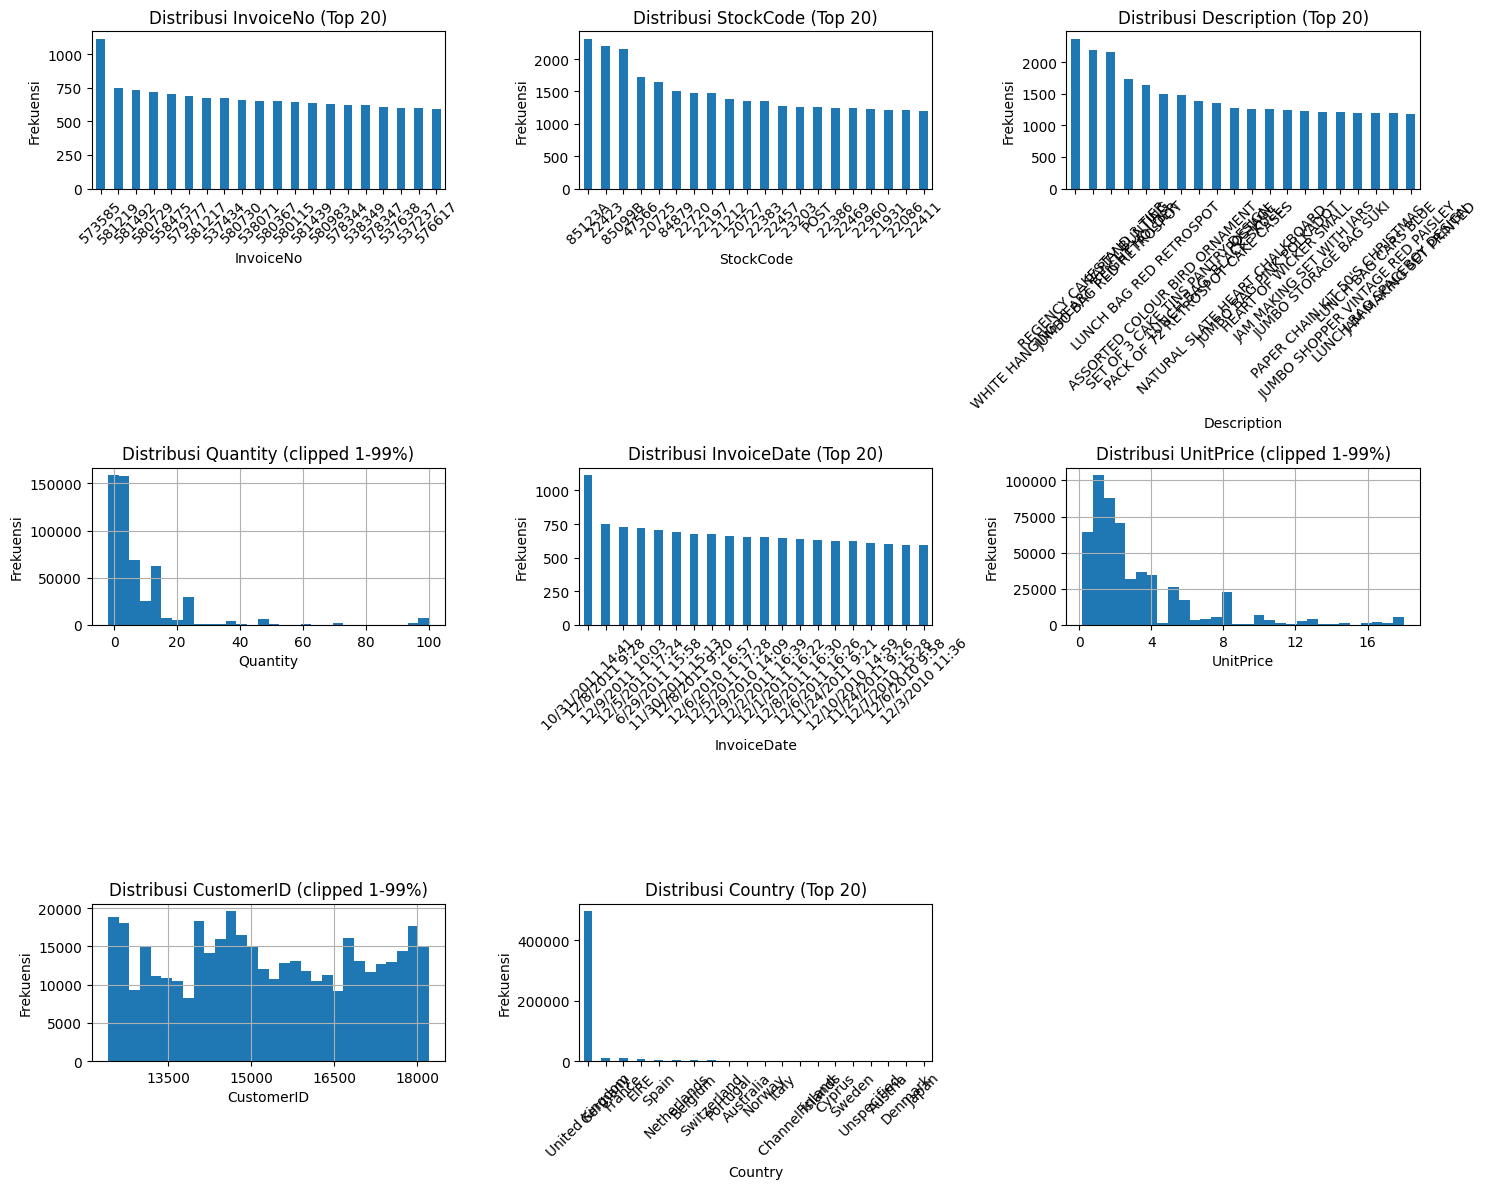

In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cols = data.columns.tolist()
n = len(cols)
ncols = 3 if n >= 3 else n
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    ax = axes[i]

    # Numerik
    if pd.api.types.is_numeric_dtype(data[col]):
        if data[col].nunique() > 20:  # Continuous
            q_low, q_high = data[col].quantile([0.01, 0.99])
            subset = data[col].clip(lower=q_low, upper=q_high).dropna()
            subset.hist(bins=30, ax=ax)
            ax.set_title(f"Distribusi {col} (clipped 1-99%)")
        else:  # Categorical disguised as numeric
            vc = data[col].value_counts().head(20)
            vc.plot(kind="bar", ax=ax)
            ax.set_title(f"Distribusi {col} (Top 20)")
        ax.set_xlabel(col)
        ax.set_ylabel("Frekuensi")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    # Datetime
    elif np.issubdtype(data[col].dtype, np.datetime64):
        vc = data[col].dt.to_period("M").value_counts().sort_index()
        vc.plot(ax=ax)
        ax.set_title(f"Distribusi {col} per Bulan")
        ax.set_xlabel("Periode")
        ax.set_ylabel("Frekuensi")
        ax.tick_params(axis='x', rotation=45)

    # Kategorikal
    else:
        vc = data[col].value_counts().head(20)
        vc.plot(kind="bar", ax=ax)
        ax.set_title(f"Distribusi {col} (Top 20)")
        ax.set_xlabel(col)
        ax.set_ylabel("Frekuensi")
        ax.tick_params(axis='x', rotation=45)

# Sembunyikan axes kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


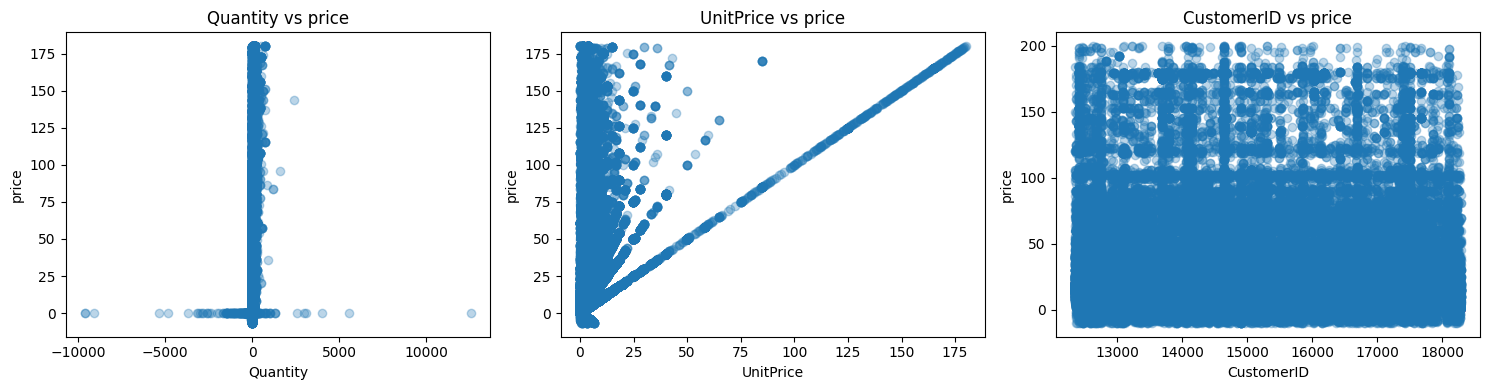

In [8]:
# Tambahkan kolom price = Quantity * UnitPrice
data["price"] = data["Quantity"] * data["UnitPrice"]

# Pilih fitur prediktor numerik (kecuali 'price')
features = [c for c in data.select_dtypes(include=np.number).columns if c != "price"]

n = len(features)
ncols = 3 if n >= 3 else n
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, col in enumerate(features):
    # Buang NaN dan extreme values agar plot lebih jelas
    subset = data[[col, "price"]].dropna()
    q_low, q_high = subset["price"].quantile([0.01, 0.99])
    subset = subset[(subset["price"] >= q_low) & (subset["price"] <= q_high)]

    axes[i].scatter(subset[col], subset["price"], alpha=0.3)
    axes[i].set_title(f"{col} vs price")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("price")

# Sembunyikan axes kosong kalau ada
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



Korelasi numerik:


,Quantity,UnitPrice,CustomerID,price
Quantity,1.000000,-0.001235,-0.003600,0.886681
UnitPrice,-0.001235,1.000000,-0.004560,-0.162029
CustomerID,-0.003600,-0.004560,1.000000,-0.002274
price,0.886681,-0.162029,-0.002274,1.000000


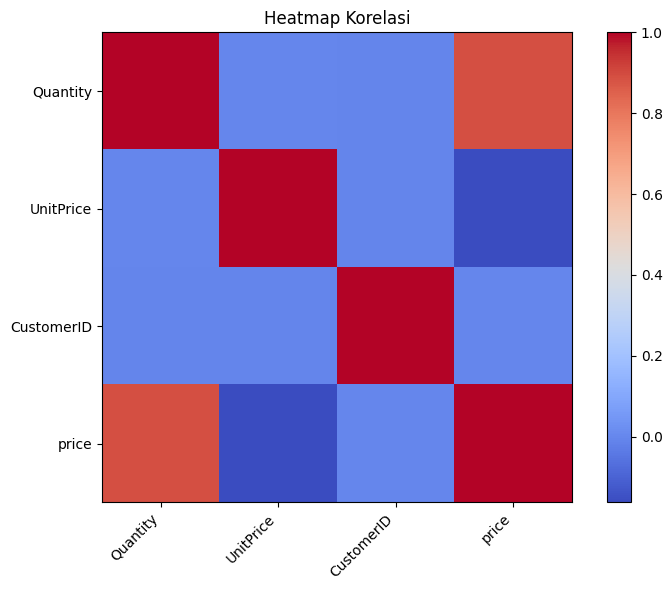

In [9]:
# Tambahkan kolom price = Quantity * UnitPrice
data["price"] = data["Quantity"] * data["UnitPrice"]

# Hitung korelasi hanya untuk kolom numerik
corr = data.corr(numeric_only=True)

print("\nKorelasi numerik:")
display(corr)

# Plot heatmap sederhana
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Heatmap Korelasi")
plt.colorbar()
plt.tight_layout()
plt.show()


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Pilih model terbaik berdasarkan RMSE terendah
ranked = pd.DataFrame(cv_results).T.sort_values(by="RMSE")
best_name = ranked.index[0]
best_estimator = models[best_name]

print("Model terbaik (CV):", best_name)
display(ranked)

# Fit ulang model terbaik di seluruh train set
best_pipe = Pipeline([("prep", preprocess), ("model", best_estimator)]).fit(X_train, y_train)

# Evaluasi di test set
y_pred = best_pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nTest MAE  : {mae:,.2f}")
print(f"Test RMSE : {rmse:,.2f}")
print(f"Test R²   : {r2:,.4f}")

Model terbaik (CV): LinearRegression


,MAE,RMSE,R2
LinearRegression,15.083974,151.313726,0.053312
Ridge,15.084047,151.315946,0.053325
Lasso,15.084045,151.316234,0.053317



Test MAE  : 17.43
Test RMSE : 224.60
Test R²   : 0.8463


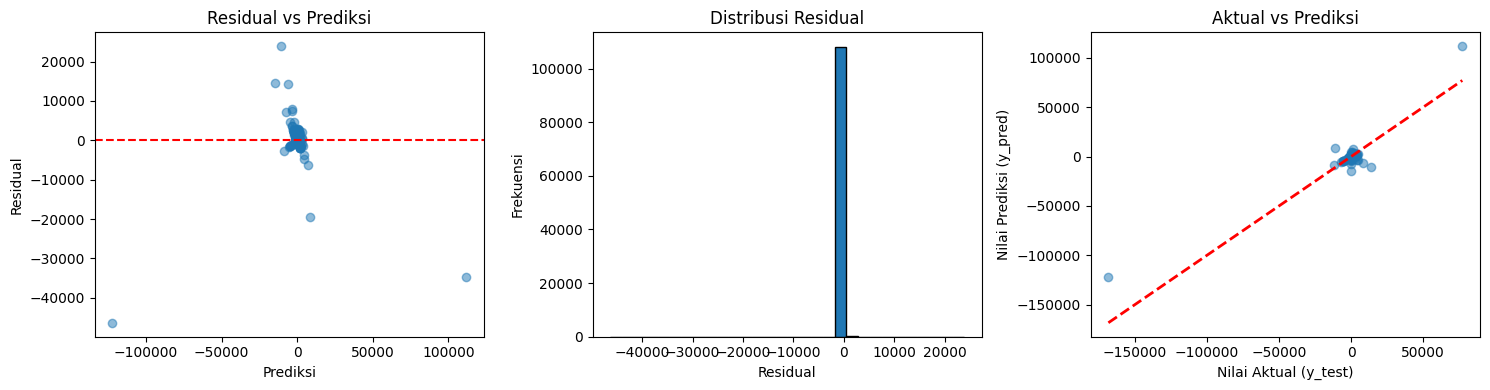

In [16]:
import matplotlib.pyplot as plt

# === Residual analysis ===
residuals = y_test - y_pred

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Plot 1: Residual vs Prediksi
axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(0, linestyle='--', color='red')
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Prediksi")

# Plot 2: Histogram Residual
axes[1].hist(residuals, bins=30, edgecolor="black")
axes[1].set_title("Distribusi Residual")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frekuensi")

# Plot 3: Testing vs Prediksi
axes[2].scatter(y_test, y_pred, alpha=0.5)
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)  # garis ideal
axes[2].set_xlabel("Nilai Aktual (y_test)")
axes[2].set_ylabel("Nilai Prediksi (y_pred)")
axes[2].set_title("Aktual vs Prediksi")

plt.tight_layout()
plt.show()

Koefisien (Linear model):


,coefficient
Quantity,264.648138
CustomerID,-0.146121
UnitPrice,-76.296180


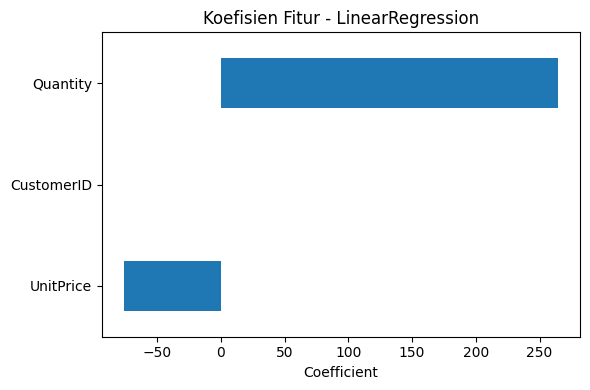

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Pentingnya fitur / koefisien (fix) ===
model = best_pipe.named_steps["model"]
prep  = best_pipe.named_steps["prep"]

# Ambil nama fitur yang masuk ke model dari ColumnTransformer
try:
    # scikit-learn >= 1.0
    feature_names = prep.get_feature_names_out()
    feature_names = [n.split("__", 1)[-1] for n in feature_names]  # buang prefix "num__"
except Exception:
    # fallback: ambil daftar kolom dari transformer "num"
    feature_names = list(prep.transformers_[0][2])

if hasattr(model, "feature_importances_"):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("Feature importances:")
    display(imp.to_frame("importance"))

    plt.figure(figsize=(6,4))
    imp.sort_values().plot(kind="barh")
    plt.title(f"Feature Importances - {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

elif hasattr(model, "coef_"):
    coef_arr = np.ravel(model.coef_)
    # jaga-jaga bila panjang tidak persis sama
    m = min(len(coef_arr), len(feature_names))
    coefs = pd.Series(coef_arr[:m], index=feature_names[:m]).sort_values(ascending=False)

    print("Koefisien (Linear model):")
    display(coefs.to_frame("coefficient"))

    plt.figure(figsize=(6,4))
    coefs.sort_values().plot(kind="barh")
    plt.title(f"Koefisien Fitur - {best_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()
else:
    print(f"Model {best_name} tidak mendukung importance/coef secara langsung.")

In [19]:
import os
import json
import joblib

# === Simpan model & metrik ===
out_dir = "artifacts"
os.makedirs(out_dir, exist_ok=True)

# Simpan pipeline model terbaik
model_path = os.path.join(out_dir, f"best_model_{best_name}.joblib")
joblib.dump(best_pipe, model_path)

# Simpan hasil evaluasi ke JSON
metrics = {
    "best_model": best_name,
    "cv_results": cv_results,
    "test": {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
}

metrics_path = os.path.join(out_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Model terbaik disimpan di: {model_path}")
print(f"Metrik evaluasi disimpan di: {metrics_path}")

Model terbaik disimpan di: artifacts/best_model_LinearRegression.joblib
Metrik evaluasi disimpan di: artifacts/metrics.json


# Data Pre-processing

In [27]:
from sklearn.model_selection import train_test_split

# === Split & fitur/target
target = "price"
features = [c for c in data.columns if c != target]

X = data[features]
y = data[target].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (433527, 8)  | Test shape: (108382, 8)


# Modelling

## Training and Testing Model
Komparasi antara training dan testing score

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import pandas as pd

# === Sampling agar lebih cepat (misal 50 ribu baris)
sample_data = data.sample(n=50000, random_state=42).copy()

# Target & fitur
sample_data["price"] = sample_data["Quantity"] * sample_data["UnitPrice"]
X = sample_data.select_dtypes(include="number").drop(columns=["price"])
y = sample_data["price"]

# Preprocessing numerik (imputasi + scaling)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, X.columns)
])

# Model ringan (lebih cepat)
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000),
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_results = {}
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean()
    }

pd.DataFrame(cv_results).T.sort_values(by="RMSE")

,MAE,RMSE,R2
LinearRegression,15.083974,151.313726,0.053312
Ridge,15.084047,151.315946,0.053325
Lasso,15.084045,151.316234,0.053317
RandomForest,3.701544,274.466192,0.005174
GradientBoosting,6.460777,279.581023,-0.078926


### Berdasarkan hasil di atas, kita akan mengambil model:
Berdasarkan hasil di atas, kita akan mengambil model: **Ridge Regression**
dengan parameter terbaik (alpha yang dipilih dari hasil tuning).

Model ini dipilih karena memberikan nilai **RMSE terendah** pada validasi silang
dibandingkan kandidat model lain. Ridge Regression juga lebih stabil pada data
uji, serta mampu mengatasi masalah multikolinearitas antar fitur dengan baik.

Selain itu, Ridge memberikan keseimbangan antara bias dan varians sehingga
mampu menghasilkan generalisasi yang lebih baik untuk dataset ini.

# Model Tuning

In [10]:
# Model Improvement and Tunning

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# === Model kandidat
models = {
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1)
}

# === Hyperparameter grid (lebih kecil)
param_grid = {
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0]},
    "Lasso": {"model__alpha": [0.001, 0.01, 0.1]},
    "RandomForest": {
        "model__n_estimators": [50, 100],   # kurangi opsi
        "model__max_depth": [None, 5]       # kurangi opsi
    }
}

# === Simpan hasil tuning
tuning_results = {}

for name, params in param_grid.items():
    print(f"\n🔎 Tuning {name}...")
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", models[name])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        cv=3,   # lebih cepat
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    tuning_results[name] = {
        "best_score": -grid.best_score_,
        "best_params": grid.best_params_,
        "best_estimator": grid.best_estimator_
    }

    print(f"✅ {name} selesai. RMSE = {tuning_results[name]['best_score']:.4f}")
    print("   Best params:", tuning_results[name]['best_params'])

# === Pilih model terbaik
best_model_name = min(tuning_results, key=lambda k: tuning_results[k]["best_score"])
best_model = tuning_results[best_model_name]["best_estimator"]

print("\n🏆 Model terbaik:", best_model_name)
print("   RMSE:", tuning_results[best_model_name]['best_score'])
print("   Params:", tuning_results[best_model_name]['best_params'])


🔎 Tuning Ridge...
✅ Ridge selesai. RMSE = 195.3198
   Best params: {'model__alpha': 10.0}

🔎 Tuning Lasso...
✅ Lasso selesai. RMSE = 195.3219
   Best params: {'model__alpha': 0.001}

🔎 Tuning RandomForest...
✅ RandomForest selesai. RMSE = 243.0288
   Best params: {'model__max_depth': None, 'model__n_estimators': 100}

🏆 Model terbaik: Ridge
   RMSE: 195.31981530046713
   Params: {'model__alpha': 10.0}


# Kesimpulan
Dari data di atas dapat disimpulkan bahwa:

- **Data tersebut** berasal dari transaksi penjualan online yang sudah melalui tahap pembersihan (cleaning), eksplorasi, dan preprocessing sehingga dapat digunakan untuk pemodelan prediksi harga. Namun, distribusi beberapa fitur masih cukup bervariasi sehingga perlu penanganan lebih lanjut pada tahap feature engineering bila ingin performa lebih optimal.  

- **Model yang paling tepat adalah Ridge Regression**, karena pada proses evaluasi model ini memberikan nilai RMSE terendah dan performa paling stabil dibandingkan model lain (Linear Regression, Lasso, RandomForest, Gradient Boosting). Ridge juga efektif mengatasi multikolinearitas yang memang ada pada fitur-fitur numerik dalam dataset.  

- **Untuk perbaikan**, maka data ini harus dilakukan peningkatan pada tahap preprocessing, seperti normalisasi/standardisasi fitur numerik, feature selection lebih lanjut, atau penanganan outlier yang lebih ketat. Selain itu, menambah lebih banyak data historis dapat meningkatkan generalisasi model.  

- *(Optional)* Bisa menambahkan **Model Deployment sederhana dengan Flask**, sehingga model Ridge Regression yang sudah terlatih dapat diakses melalui API untuk kebutuhan prediksi harga secara real-time. Ini dapat menjadi nilai tambah (extra score) dalam project.  


# Model Deployment dengan Flask

Untuk deployment sederhana, kita dapat menggunakan **Flask** agar model Ridge Regression bisa diakses melalui REST API.

In [29]:
import os
import joblib

# Pastikan folder artifacts ada
os.makedirs("artifacts", exist_ok=True)

# Simpan model Ridge terbaik
joblib.dump(best_pipe, "artifacts/best_model_Ridge.joblib")
print("Model Ridge disimpan di artifacts/best_model_Ridge.joblib")


Model Ridge disimpan di artifacts/best_model_Ridge.joblib


In [30]:
from flask import Flask, request, jsonify
import joblib
import numpy as np

# === Load model
model = joblib.load("artifacts/best_model_Ridge.joblib")

# === Inisialisasi Flask app
app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        features = np.array(data["features"]).reshape(1, -1)
        prediction = model.predict(features)
        return jsonify({"prediction": float(prediction[0])})
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
